In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks

In [32]:
df = pd.read_csv("..\\Data\\2.595.0-Vannstand-inst-v1.csv", skiprows=1, delimiter=';', decimal=',')
df.drop(columns=["Korrigert", "Kontrollert"], inplace=True)
print(len(df))
df.dropna(inplace=True)
df["Tidspunkt"] = pd.to_datetime(df["Tidspunkt"])
df = df.set_index("Tidspunkt").resample("D").max().reset_index()

peaks = find_peaks(df["Vannstand (m)"].values, height=352, distance=30)
exceedances = df["Vannstand (m)"][peaks[0]]
print(f"number of peaks: {len(peaks[0])}")

210374
number of peaks: 49


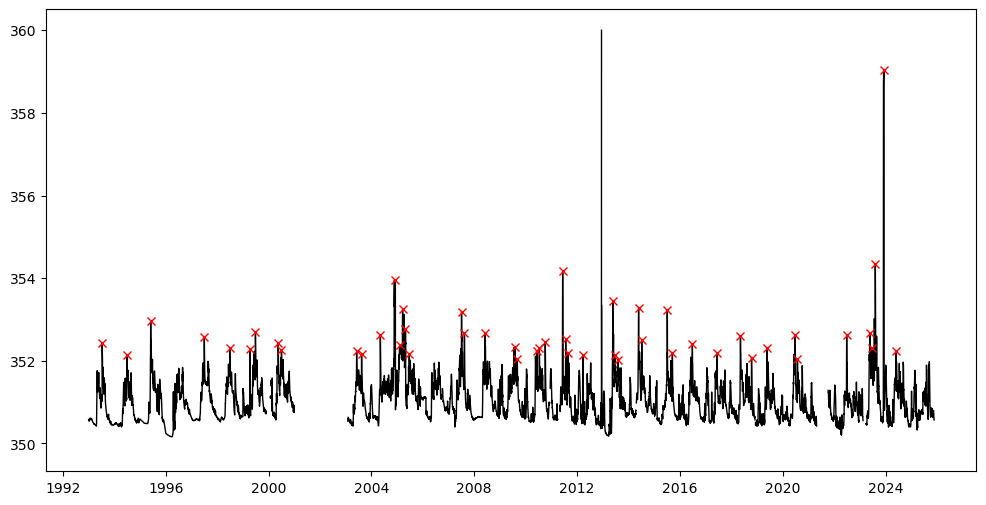

In [33]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df["Tidspunkt"], df["Vannstand (m)"], label="Water Level", color='black', lw=1)
ax.plot(df["Tidspunkt"].iloc[peaks[0]], exceedances, "x", label="Peaks", color='red')

(array([22., 16.,  2.,  4.,  1.,  1.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([352.02  , 352.3709, 352.7218, 353.0727, 353.4236, 353.7745,
        354.1254, 354.4763, 354.8272, 355.1781, 355.529 , 355.8799,
        356.2308, 356.5817, 356.9326, 357.2835, 357.6344, 357.9853,
        358.3362, 358.6871, 359.038 ]),
 <BarContainer object of 20 artists>)

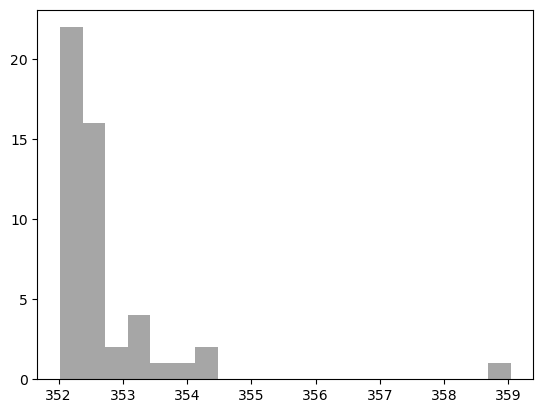

In [35]:
plt.hist(exceedances, bins=20, color='gray', alpha=0.7)